# Data Management – GreenGarten Versandhandel GmbH

Explorative Bereinigung von `data/raw/verkaufe.csv` (Verkaufsdaten von
600 Produkten über 24 Monate). Ziel dieses Notebooks: die Rohdaten Schritt
für Schritt verstehen, alle Format- und Datenqualitätsprobleme
identifizieren und zu `df_verkaufe_clean` bereinigen – jeder Schritt wird
begründet und am tatsächlichen Ergebnis überprüft, bevor der nächste
folgt. `verkaufe.csv` wird dabei nur gelesen, nie verändert.

**Agenda:**

1. **Rohdaten laden** – einlesen und erster visueller Eindruck.
2. **Statistik-Check** – Datentypen, Wertebereiche und fehlende Werte
   vollständig erfassen, bevor irgendetwas verändert wird.
3. **Data Cleaning** – Duplikate, Schreibweisen, Datums- und
   Preisformate sowie die Logik hinter strukturell fehlenden Werten.
4. **Ausreißer suchen** – `umsatz_eur` auf unplausible Werte prüfen und
   über eine Kreuzvalidierung exakt korrigieren.
5. **Verbleibende Spalten bereinigen** – `lagerbestand`,
   `bewertungen_durchschnitt` und `marketingbudget_eur`.
6. **Abschluss** – finale Spaltenreihenfolge, CSV-Export und
   Zusammenfassung aller gefundenen Datenfehler.

## 1 Rohdaten laden

### 1.1 Bibliotheken importieren

`pandas`/`numpy` für die eigentliche Datenverarbeitung, `matplotlib`/
`seaborn` für spätere Visualisierungen (z. B. Missing-Data-Heatmap).

In [48]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

### 1.2 Rohdaten einlesen

Die Rohdaten werden aus `verkaufe.csv` geladen, um einen ersten Überblick über Umfang und Struktur des Datensatzes zu erhalten.

In [49]:
path = "../data/raw/verkaufe.csv"
df_verkaufe_raw = pd.read_csv(path)
df_verkaufe_raw.shape

(14430, 16)

Die eingelesene Datei enthält 14.430 Zeilen und 16 Spalten. Die erwartete Zeilenanzahl liegt bei 14.400, was auf doppelte Datensätze hinweist, die später geprüft werden.

### 1.3 Erste Übersicht

Ein kurzer Blick auf die obersten Zeilen zeigt Aufbau, Formatierungen und erste mögliche Auffälligkeiten im Datensatz.

In [50]:
df_verkaufe_raw.head()

,produkt_id,kategorie,hersteller,monat,monat_idx,preis_eur,wettbewerber_preis_eur,marketingbudget_eur,kampagne_aktiv,lagerbestand,bewertungen_durchschnitt,bewertungen_anzahl,vormonat_umsatz_eur,letzte_3_monate_umsatz_eur_avg,vorjahr_monat_umsatz_eur,umsatz_eur
0,PR-0000,Saatgut,Hortica,01.2024,1,"1,50 €",1.41,89.61,0,67,3.70,39,NaN,NaN,NaN,6.12
1,PR-0000,Saatgut,Hortica,2024-02,2,1.5,1.69,88.16,1,69,3.70,39,6.12,6.12,NaN,13.64
2,PR-0000,Saatgut,Hortica,2024-03,3,1.5,1.61,117.38,1,64,3.70,39,13.64,9.88,NaN,16.75
3,PR-0000,Saatgut,Hortica,04.2024,4,1.5,1.40,99.85,0,72,3.70,39,16.75,12.17,NaN,22.68
4,PR-0000,Saatgut,Hortica,05/2024,5,1.5,1.45,101.72,0,35,3.70,39,22.68,17.69,NaN,11.98


Die Vorschau macht uneinheitliche Datums- und Preisformate sichtbar sowie strukturelle Lücken in abgeleiteten Umsatzspalten. Diese Hinweise markieren die ersten Bereiche für die Bereinigung.

## 2 Statistik-Check

Bevor irgendetwas bereinigt wird, verschafft dieser Abschnitt einen vollständigen Überblick über Spalten, Datentypen, Wertebereiche und fehlende Werte – Grundlage für alle folgenden Entscheidungen.

### 2.1 Tabellen-Information

Die Tabellen‑Information liefert einen kompakten Überblick über Datentypen und Befüllungsgrade aller Spalten. Dadurch wird sofort sichtbar, wo Formatabweichungen auftreten und in welchen Bereichen fehlende Werte vorhanden sind.

In [51]:
df_verkaufe_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 14430 entries, 0 to 14429
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   produkt_id                      14430 non-null  str    
 1   kategorie                       14430 non-null  str    
 2   hersteller                      14430 non-null  str    
 3   monat                           14430 non-null  str    
 4   monat_idx                       14430 non-null  int64  
 5   preis_eur                       14430 non-null  str    
 6   wettbewerber_preis_eur          14430 non-null  float64
 7   marketingbudget_eur             13997 non-null  float64
 8   kampagne_aktiv                  14430 non-null  int64  
 9   lagerbestand                    14430 non-null  str    
 10  bewertungen_durchschnitt        13854 non-null  float64
 11  bewertungen_anzahl              14430 non-null  int64  
 12  vormonat_umsatz_eur             13828 non-n

Mehrere Spalten weisen unerwartete Datentypen und unterschiedliche Anteile fehlender Werte auf. Diese Punkte bilden die Grundlage für die folgenden Bereinigungsschritte.

### 2.2 Statistical Exploration

Die statistische Übersicht zeigt Wertebereiche numerischer Spalten und ermöglicht eine erste Einschätzung zu Ausreißern und ungewöhnlichen Verteilungen.

In [52]:
df_verkaufe_raw.describe(include=['float', 'int']).T

,count,mean,std,min,25%,50%,75%,max
monat_idx,14430.00,6.50,3.45,1.00,3.25,7.00,9.00,12.00
wettbewerber_preis_eur,14430.00,26.17,23.53,1.28,8.01,20.33,34.86,164.70
marketingbudget_eur,13997.00,89.71,30.10,0.00,69.10,88.09,108.83,236.79
kampagne_aktiv,14430.00,0.11,0.32,0.00,0.00,0.00,0.00,1.00
bewertungen_durchschnitt,13854.00,3.51,0.69,1.50,3.00,3.50,4.00,5.00
bewertungen_anzahl,14430.00,40.20,6.09,24.00,36.00,40.00,44.00,59.00
vormonat_umsatz_eur,13828.00,526.50,962.26,1.71,71.61,207.49,579.15,20617.85
letzte_3_monate_umsatz_eur_avg,14429.00,517.94,899.40,1.96,76.80,214.65,580.63,16162.51
vorjahr_monat_umsatz_eur,7210.00,514.78,941.20,1.82,69.34,204.81,565.96,20617.85
umsatz_eur,14430.00,638.18,10442.64,-150.00,70.25,202.89,567.87,999999.00


**Auffälligkeiten in der numerischen Übersicht:**

- `umsatz_eur`: Minimum `-150,00 €`, Maximum `999.999,00 €`. Ein
  negativer Umsatz ist fachlich nicht möglich, und `999.999` liegt
  weit außerhalb der sonstigen Größenordnung (Mittelwert `638 €`,
  Median `≈ 203 €`) – klassische Platzhalter-/Erfassungsfehler.
  Std-Abweichung (`10.442`) ist dadurch selbst stark verzerrt.
- `vormonat_umsatz_eur` (13.828), `letzte_3_monate_umsatz_eur_avg`
  (14.429) und `vorjahr_monat_umsatz_eur` (7.210) haben spürbar
  niedrigere `count`-Werte als die 14.430 Zeilen insgesamt – das sind
  die bereits in 2.1 gesehenen fehlenden Werte.
- `marketingbudget_eur` (13.997) und `bewertungen_durchschnitt`
  (13.854) ebenso.
- `wettbewerber_preis_eur`, `kampagne_aktiv`, `bewertungen_anzahl` und
  `monat_idx` sind vollständig befüllt und wirken auf den ersten Blick
  plausibel.

Anschließend folgt dieselbe Übersicht für die kategorischen und Text‑Spalten, um auch dort Struktur, Vielfalt der Ausprägungen und mögliche Formatabweichungen sichtbar zu machen.

In [53]:
df_verkaufe_raw.describe(include=['object', 'str'])

,produkt_id,kategorie,hersteller,monat,preis_eur,lagerbestand
count,14430,14430,14430,14430,14430,14430
unique,600,24,6,72,909,389
top,PR-0191,Pflanzen,Vivero,11.2024,1.5,47
freq,26,4218,2672,226,512,172


**Auffälligkeiten in der kategorischen Übersicht:**

- `produkt_id`: 600 eindeutige Werte – passt zur erwarteten Produktzahl.
- `kategorie`: **24** eindeutige Werte, obwohl fachlich nur 6 Kategorien
  existieren (Pflanzen, Werkzeuge, Saatgut, Toepfe, Duengemittel,
  Bewaesserung) – Schreibweisen-Varianten (Groß-/Kleinschreibung,
  Umlaute, Abkürzungen wie `DUENGER`/`Saat`).
- `hersteller`: 6 eindeutige Werte – sauber, kein Bereinigungsbedarf.
- `monat`: **72** eindeutige Werte statt der erwarteten 24 (2 Jahre ×
  12 Monate) – exakt das Dreifache, passend zu den 3 Datumsformaten aus
  1.3.
- `preis_eur`: **909** eindeutige Werte – ungewöhnlich viele für eine
  Spalte, die pro Produkt konstant sein sollte; auch hier ein Hinweis
  auf die gemischten Text-/Zahl-Formate.
- `lagerbestand`: 389 eindeutige Werte, als Text gespeichert (siehe 2.1).

### 2.3 Fehlende Werte je Spalte

Die folgende Übersicht zählt pro Spalte, wie viele Werte tatsächlich fehlen. Dies dient als
Grundlage, um im nächsten Schritt zwischen zwei Sachverhalten zu unterscheiden. Erstens sind die Lücken
strukturell erklärbar oder handelt es sich zweitens um echte Datenfehler.

In [54]:
df_verkaufe_raw.isna().sum()

produkt_id                           0
kategorie                            0
hersteller                           0
monat                                0
monat_idx                            0
preis_eur                            0
wettbewerber_preis_eur               0
marketingbudget_eur                433
kampagne_aktiv                       0
lagerbestand                         0
bewertungen_durchschnitt           576
bewertungen_anzahl                   0
vormonat_umsatz_eur                602
letzte_3_monate_umsatz_eur_avg       1
vorjahr_monat_umsatz_eur          7220
umsatz_eur                           0
dtype: int64

**Einordnung der fehlenden Werte** (wird in der Bereinigung weiter
unten im Detail behandelt):

- `marketingbudget_eur` (433) und `bewertungen_durchschnitt` (576) ohne
  erkennbares Muster – vermutlich echte Datenlücken.
- `vormonat_umsatz_eur` (602) und `vorjahr_monat_umsatz_eur` (7.220)
  strukturell erklärbar: für den 1. Verkaufsmonat eines Produkts gibt es
  keinen Vormonat, für das 1. Jahr des Datensatzes (2024) kein Vorjahr.
- `letzte_3_monate_umsatz_eur_avg` fehlt dagegen nur in **einer**
  einzigen Zeile – auffällig wenig für eine Spalte, die laut Definition
  ("Durchschnitt der letzten 3 Monate") erst ab dem 4. Verkaufsmonat
  eines Produkts überhaupt einen Wert haben kann. Das deutet auf einen
  eigenen Datenqualitätsfehler hin, der separat untersucht werden muss.
- `umsatz_eur` selbst hat 0 fehlende Werte – die in 2.2 gefundenen
  Ausreißer (`-150`, `999.999`) stecken also als **Werte**, nicht als
  `NaN`, in der Spalte.


Die Analyse macht deutlich, welche Spalten später gezielt ergänzt oder bereinigt werden müssen, um eine vollständige und konsistente Datenbasis für die weiteren Schritte sicherzustellen.

Welche Spalten haben überhaupt fehlende Werte (als Boolean-Maske)?

In [55]:
spalten_mit_nan = df_verkaufe_raw.columns[df_verkaufe_raw.isna().sum() > 0]
df_verkaufe_raw[spalten_mit_nan].head(0).T


""
marketingbudget_eur
bewertungen_durchschnitt
vormonat_umsatz_eur
letzte_3_monate_umsatz_eur_avg
vorjahr_monat_umsatz_eur


Damit wird deutlich, welche Spalten später gezielt ergänzt oder bereinigt werden müssen, um eine konsistente Datenbasis sicherzustellen.

### 2.4 Eindeutige Werte je Spalte (Stichprobe)

Die folgende Stichprobe zeigt die ersten eindeutigen Werte jeder Spalte. Dadurch wird sichtbar, wie vielfältig die Ausprägungen sind und in welchen Bereichen uneinheitliche Schreibweisen oder ungewöhnliche Werte auftreten.

In [56]:
for col in df_verkaufe_raw.columns:
    print(f"\nSpalte: {col}")
    print(df_verkaufe_raw[col].unique()[:20])


Spalte: produkt_id
<StringArray>
['PR-0000', 'PR-0001', 'PR-0002', 'PR-0003', 'PR-0004', 'PR-0005', 'PR-0006',
 'PR-0007', 'PR-0008', 'PR-0009', 'PR-0010', 'PR-0011', 'PR-0012', 'PR-0013',
 'PR-0014', 'PR-0015', 'PR-0016', 'PR-0017', 'PR-0018', 'PR-0019']
Length: 20, dtype: str

Spalte: kategorie
<StringArray>
[     'Saatgut', 'Bewaesserung', 'bewaesserung', 'Duengemittel',
      'DUENGER',    'Werkzeuge',     'Pflanzen',      'Pflanze',
     'PFLANZEN',       'Toepfe',  'Düngemittel', 'BEWAESSERUNG',
      'saatgut',      'SAATGUT',     'pflanzen',       'toepfe',
 'duengemittel',         'Saat',    'werkzeuge',    'WERKZEUGE']
Length: 20, dtype: str

Spalte: hersteller
<StringArray>
['Hortica', 'GartenStern', 'BioGruen', 'Vivero', 'Floraplan', 'Garda Tools']
Length: 6, dtype: str

Spalte: monat
<StringArray>
['01.2024', '2024-02', '2024-03', '04.2024', '05/2024', '2024-06', '2024-07',
 '2024-08', '09.2024', '2024-10', '11.2024', '12.2024', '01.2025', '2025-02',
 '03.2025', '04/2025'

Die Übersicht macht deutlich, welche Spalten stabile Stammdaten enthalten und wo Formatabweichungen oder unerwartet viele Ausprägungen auf eine notwendige Bereinigung hinweisen.

- `kategorie`: in der Stichprobe bereits `'Saatgut'`, `'saatgut'`,
  `'SAATGUT'`, `'Saat'`, `'Bewaesserung'`, `'bewaesserung'`,
  `'BEWAESSERUNG'`, `'Pflanzen'`, `'Pflanze'`, `'PFLANZEN'` etc.
  sichtbar – Groß-/Kleinschreibung, Umlaut-Varianten und Abkürzungen
  gemischt.
- `monat`: `'01.2024'`, `'2024-02'`, `'2024-03'`, `'04.2024'`,
  `'05/2024'` – alle drei Formate (`MM.YYYY`, `YYYY-MM`, `MM/YYYY`)
  treten nebeneinander auf.
- `preis_eur`: `'1,50 €'` neben `'1.5'`, `'102.04'` – Text-mit-Euro-Komma
  und reine Zahl gemischt.
- `lagerbestand`: in der 20er-Stichprobe wirken die Werte rein
  numerisch (`'67'`, `'69'`, ...), aber als `str` gespeichert (siehe
  2.1). Eine gezielte Prüfung zeigt, dass ein Teil der Zeilen zusätzlich
  einen Text-Zusatz trägt:

Die folgende Prüfung zeigt, ob die Spalte lagerbestand neben numerischen Angaben auch Text‑Zusätze enthält. Dadurch wird sichtbar, in welchen Zeilen fehlerhafte oder uneinheitliche Eingaben vorkommen.

In [57]:
lagerbestand_mit_text = df_verkaufe_raw["lagerbestand"].astype(str).str.contains("[A-Za-z]")
print(f"Zeilen mit Text-Zusatz in 'lagerbestand': {lagerbestand_mit_text.sum()} von {len(df_verkaufe_raw)}")
df_verkaufe_raw.loc[lagerbestand_mit_text, "lagerbestand"].unique()[:5]

Zeilen mit Text-Zusatz in 'lagerbestand': 288 von 14430


<StringArray>
['91 Stueck', '45 Stueck', '154 Stueck', '36 Stueck', '50 Stueck']
Length: 5, dtype: str

→ Werte wie `'91 Stueck'` statt `91`. Diese waren in der 20er-Stichprobe oben
nicht sichtbar, weil diese Zeilen dort nicht unter den ersten 20 lagen. Insgesamt sind 288 Zeilen betroffen.
**Und die 30 zusätzlichen Zeilen aus 1.2?**

In [58]:
anzahl_duplikate = df_verkaufe_raw.duplicated().sum()
print(f"Vollstaendige Duplikate (alle Spalten identisch): {anzahl_duplikate}")

Vollstaendige Duplikate (alle Spalten identisch): 30


Die Untersúchung bestätigt 30 vollständige Duplikate. Das ist exakt die Differenz
zwischen den 14.430 Rohzeilen und den erwarteten 14.400 (600 Produkte ×
24 Monate).

## 3 Data Cleaning

### 3.1 `df_verkaufe_clean` anlegen

Ab hier wird nur noch mit einer Kopie gearbeitet – `df_verkaufe_raw`
bleibt unverändert als Referenz auf die Rohdaten erhalten.

In [59]:
df_verkaufe_clean = df_verkaufe_raw.copy()
df_verkaufe_clean.shape

(14430, 16)

Noch identisch zu den Rohdaten (14.430 Zeilen × 16 Spalten) – die
eigentliche Bereinigung (Formate, Duplikate, fehlende Werte, Ausreißer)
folgt in den nächsten Schritten.

### 3.2 Duplikate entfernen

Zuerst werden alle Duplikate gesucht und gezählt, bevor überhaupt etwas
gelöscht wird – damit nachvollziehbar bleibt, wie viele Zeilen betroffen
sind und ob es sich wirklich um vollständige, exakte Duplikate handelt
(nicht nur gleiche `produkt_id` + `monat`).

**Suchen:** Welche Zeilen sind (inkl. ihres jeweiligen Originals) an einem Duplikat beteiligt?

In [60]:
duplikat_zeilen = df_verkaufe_clean[df_verkaufe_clean.duplicated(keep=False)]
duplikat_zeilen.sort_values(["produkt_id", "monat"]).head(60)

,produkt_id,kategorie,hersteller,monat,monat_idx,preis_eur,wettbewerber_preis_eur,marketingbudget_eur,kampagne_aktiv,lagerbestand,bewertungen_durchschnitt,bewertungen_anzahl,vormonat_umsatz_eur,letzte_3_monate_umsatz_eur_avg,vorjahr_monat_umsatz_eur,umsatz_eur
439,PR-0018,Saatgut,Hortica,2024-08,8,7.26,7.26,65.98,0,56,3.30,39,63.81,83.33,NaN,40.60
14417,PR-0018,Saatgut,Hortica,2024-08,8,7.26,7.26,65.98,0,56,3.30,39,63.81,83.33,NaN,40.60
766,PR-0031,Pflanzen,Floraplan,11/2025,11,36.52,37.49,70.92,0,46,3.00,41,221.99,264.50,100.49,128.35
14402,PR-0031,Pflanzen,Floraplan,11/2025,11,36.52,37.49,70.92,0,46,3.00,41,221.99,264.50,100.49,128.35
2622,PR-0109,Pflanzen,Floraplan,2024-07,7,32.58,32.48,70.36,0,79,2.70,47,1386.48,1161.61,NaN,628.68
14420,PR-0109,Pflanzen,Floraplan,2024-07,7,32.58,32.48,70.36,0,79,2.70,47,1386.48,1161.61,NaN,628.68
2812,PR-0117,Pflanzen,BioGruen,2024-05,5,14.0,15.65,140.16,0,101,4.50,42,250.60,167.65,NaN,294.72
14425,PR-0117,Pflanzen,BioGruen,2024-05,5,14.0,15.65,140.16,0,101,4.50,42,250.60,167.65,NaN,294.72
3342,PR-0139,Bewaesserung,Garda Tools,2024-07,7,76.3,80.84,132.16,0,13,4.00,32,2670.84,1383.85,NaN,2560.08
14401,PR-0139,Bewaesserung,Garda Tools,2024-07,7,76.3,80.84,132.16,0,13,4.00,32,2670.84,1383.85,NaN,2560.08


**Zählen:** Wie viele Zeilen sind reine Wiederholungen (Original bereits vorhanden)?

In [61]:
anzahl_duplikate = df_verkaufe_clean.duplicated().sum()
print(f"Vollstaendige Duplikate (zu loeschende Zeilen): {anzahl_duplikate}")
print(f"Davon betroffene Zeilen insgesamt (Original + Kopie): {len(duplikat_zeilen)}")

Vollstaendige Duplikate (zu loeschende Zeilen): 30
Davon betroffene Zeilen insgesamt (Original + Kopie): 60


**Ergebnis:** 30 Zeilen sind reine Wiederholungen einer bereits
vorhandenen Zeile (60 Zeilen insgesamt an Duplikaten beteiligt, je
Original + Kopie) – exakt die Differenz zwischen den 14.430 Rohzeilen
und den erwarteten 14.400.

**Löschen:** `drop_duplicates()` behält jeweils die erste Vorkommnis und entfernt nur die überzähligen Kopien.

In [62]:
vorher = len(df_verkaufe_clean)
df_verkaufe_clean = df_verkaufe_clean.drop_duplicates()
nachher = len(df_verkaufe_clean)

print(f"Zeilen vorher: {vorher}")
print(f"Zeilen nachher: {nachher}")
print(f"Entfernt: {vorher - nachher}")
print(f"Erwartet: 600 Produkte x 24 Monate = 14.400 -> {'passt' if nachher == 14_400 else 'passt NICHT'}")

Zeilen vorher: 14430
Zeilen nachher: 14400
Entfernt: 30
Erwartet: 600 Produkte x 24 Monate = 14.400 -> passt


Nachdem der Datensatz mehrfach geprüft wurde und die Anzahl an Duplikaten auf 30 Zeilen beziffert werden konnte, wurden diese Zeilen gelöscht.

### 3.3 `kategorie`: einheitliche Schreibweise

Da wir bereits in den Rohdaten sahen, dass es eine Vielzahl an Schreibweisen gibt, werden diese zunächst gezählt, bevor Sie anschließend vereinheitlicht werden.

In [63]:
df_verkaufe_clean["kategorie"].value_counts()

kategorie
Pflanzen        4207
Werkzeuge       2669
Saatgut         2490
Toepfe          1808
Duengemittel    1526
Bewaesserung    1268
PFLANZEN          47
pflanzen          46
Pflanze           44
werkzeuge         34
Werkzeug          29
WERKZEUGE         28
saatgut           26
SAATGUT           26
Saat              26
BEWAESSERUNG      24
TOEPFE            18
bewaesserung      16
Düngemittel       12
toepfe            12
duengemittel      12
Bewässerung       12
DUENGER           10
Töpfe             10
Name: count, dtype: int64

Die Auflistung ergibt 24 unterschiedliche Schreibweisen für nur 6 fachliche
Kategorien. Dabei treten Artefakte, wie Groß-/Kleinschreibung, Umlaut-Varianten (`ae`/`ä`) und
Abkürzungen (`Saat`/`Saatgut`, `Duenger`/`Duengemittel`) und deren Kombinationen auf.

**Bereinigen:** Jeder Wert wird zunächst normalisiert (getrimmt,
kleingeschrieben, Umlaute in `ae`/`oe`/`ue`/`ss` übersetzt) und
anschließend über eine feste Zuordnung auf eine der 6 echten Kategorien
gemappt.

In [64]:
KATEGORIE_MAPPING = {
    "pflanzen": "Pflanzen", "pflanze": "Pflanzen",
    "werkzeuge": "Werkzeuge", "werkzeug": "Werkzeuge",
    "saatgut": "Saatgut", "saat": "Saatgut",
    "toepfe": "Toepfe",
    "duengemittel": "Duengemittel", "duenger": "Duengemittel",
    "bewaesserung": "Bewaesserung",
}


def kategorie_normalisieren(wert):
    text = str(wert).strip().lower()
    text = (text.replace("ä", "ae").replace("ö", "oe")
                .replace("ü", "ue").replace("ß", "ss"))
    return text


df_verkaufe_clean["kategorie"] = (
    df_verkaufe_clean["kategorie"].apply(kategorie_normalisieren).map(KATEGORIE_MAPPING)
)
df_verkaufe_clean["kategorie"].value_counts()

kategorie
Pflanzen        4344
Werkzeuge       2760
Saatgut         2568
Toepfe          1848
Duengemittel    1560
Bewaesserung    1320
Name: count, dtype: int64

**Kontrolle:** Es sind jetzt genau 6 Kategorien; dabei treten keine unzugeordneten (`NaN`) Werte auf.

In [65]:
print(f"Eindeutige Kategorien: {df_verkaufe_clean['kategorie'].nunique()} (erwartet 6)")
print(f"Nicht zuordenbar (NaN): {df_verkaufe_clean['kategorie'].isna().sum()} (erwartet 0)")

Eindeutige Kategorien: 6 (erwartet 6)
Nicht zuordenbar (NaN): 0 (erwartet 0)


**Ergebnis:** genau 6 Kategorien, keine unzugeordneten Werte – die
Normalisierung deckt alle in 2.4 gefundenen Schreibweisen ab.

In [66]:
df_verkaufe_clean.head()

,produkt_id,kategorie,hersteller,monat,monat_idx,preis_eur,wettbewerber_preis_eur,marketingbudget_eur,kampagne_aktiv,lagerbestand,bewertungen_durchschnitt,bewertungen_anzahl,vormonat_umsatz_eur,letzte_3_monate_umsatz_eur_avg,vorjahr_monat_umsatz_eur,umsatz_eur
0,PR-0000,Saatgut,Hortica,01.2024,1,"1,50 €",1.41,89.61,0,67,3.70,39,NaN,NaN,NaN,6.12
1,PR-0000,Saatgut,Hortica,2024-02,2,1.5,1.69,88.16,1,69,3.70,39,6.12,6.12,NaN,13.64
2,PR-0000,Saatgut,Hortica,2024-03,3,1.5,1.61,117.38,1,64,3.70,39,13.64,9.88,NaN,16.75
3,PR-0000,Saatgut,Hortica,04.2024,4,1.5,1.40,99.85,0,72,3.70,39,16.75,12.17,NaN,22.68
4,PR-0000,Saatgut,Hortica,05/2024,5,1.5,1.45,101.72,0,35,3.70,39,22.68,17.69,NaN,11.98


In der oben gezeigten Vorschau ist zu sehen, dass die Spaltennamen bewusst unverändert sind. Sie entsprechen damit den urprünglichen, technischen `snake_case`-Namen aus `verkaufe.csv`
Damit bleibt die Tabelle direkt für SQL/Datenbanken nutzbar macht.

### 3.4 `monat` vereinheitlichen und `jahr` ableiten

Wie bereits im Kapitel 1.3/2.4 festgestellt, ist das Datum willkürlich als Text eingetragen worden. Im nächsten Schritt wird auf einen echten Datums-Typ vereinheitlicht.

In diesem Schritt werden die vorkommenden Datums-Typen gezählt.

In [67]:
muster = df_verkaufe_clean["monat"].astype(str).str.replace(r"\d", "#", regex=True)
muster.value_counts()

monat
##.####    4865
##/####    4782
####-##    4753
Name: count, dtype: int64

Jetzt werden alle in einen `datetime64`-Typ umgewandelt. (`YYYY-MM-DD`)

In [68]:
def monat_vereinheitlichen(wert):
    text = str(wert).replace("/", ".").replace("-", ".")
    erster_teil, zweiter_teil = text.split(".")
    if len(erster_teil) == 4:
        jahr, monat_zahl = erster_teil, zweiter_teil
    else:
        monat_zahl, jahr = erster_teil, zweiter_teil
    return pd.Timestamp(year=int(jahr), month=int(monat_zahl), day=1)


df_verkaufe_clean["monat"] = df_verkaufe_clean["monat"].apply(monat_vereinheitlichen)
print("Datentyp von 'monat' jetzt:", df_verkaufe_clean["monat"].dtype)
df_verkaufe_clean["monat"].head()

Datentyp von 'monat' jetzt: datetime64[us]


0   2024-01-01
1   2024-02-01
2   2024-03-01
3   2024-04-01
4   2024-05-01
Name: monat, dtype: datetime64[us]

Durch die vorgenommenen Maßnahmen, ist jetzt `monat` durchgehend `datetime64` und alle Einträge sind gleich formatiert.

Für die einfachere Analyse, wird im Folgenden das `jahr` aus dem `monat` abgeleitet. Diese Spalte entsteht zusätzlich und soll der bequemeren Filterung/Gruppierung nur nach Jahr dienen.

In [69]:
df_verkaufe_clean["jahr"] = df_verkaufe_clean["monat"].dt.year
df_verkaufe_clean["jahr"].value_counts().sort_index()
print(f"Eindeutige Jahre: {sorted(df_verkaufe_clean['jahr'].unique())}")
print(f"Zeilen je Jahr:\n{df_verkaufe_clean['jahr'].value_counts().sort_index()}")

Eindeutige Jahre: [np.int32(2024), np.int32(2025)]
Zeilen je Jahr:
jahr
2024    7200
2025    7200
Name: count, dtype: int64


Im Ergebnis ist jetzt durch die Extrahierung des Jahres aus dem `monat` eine einfache Filterung in der weiteren Datenanalyse möglich.

### 3.5 `preis_eur` bereinigen

In der eingangs durchgeführten Analyse wurde festgestellt, dass auch der `preis_eur` in einer großen Variation existiert. Das
`€`-Zeichen wird entfernt, Das Format auf `float` umgestellt und die Zahl auf 2 Nachkommastellen gerundet.

Gesucht werden alle Werte mit `€`-Zeichen.

In [70]:
mit_euro_zeichen = df_verkaufe_clean["preis_eur"].astype(str).str.contains("€")
print(f"Werte mit Euro-Zeichen/Komma: {mit_euro_zeichen.sum()} von {len(df_verkaufe_clean)}")
df_verkaufe_clean.loc[mit_euro_zeichen, "preis_eur"].unique()[:10]

Werte mit Euro-Zeichen/Komma: 576 von 14400


<StringArray>
[ '1,50 €', '36,77 €', '25,44 €', '33,80 €', '24,19 €', '22,44 €', '18,56 €',
 '84,15 €',  '2,73 €', '23,31 €']
Length: 10, dtype: str

Jetzt wird das `€`-Zeichen entfernt, das Komma durch einen Punkt ersetzt, in `float` umgewandelt und auf 2 Nachkommastellen gerundet.

In [71]:
def preis_bereinigen(wert):
    text = str(wert).replace("€", "").replace(",", ".").strip()
    return round(float(text), 2)


df_verkaufe_clean["preis_eur"] = df_verkaufe_clean["preis_eur"].apply(preis_bereinigen)
print("Datentyp von 'preis_eur' jetzt:", df_verkaufe_clean["preis_eur"].dtype)
df_verkaufe_clean["preis_eur"].describe()

Datentyp von 'preis_eur' jetzt: float64


count   14400.00
mean       26.18
std        23.30
min         1.50
25%         8.13
50%        20.63
75%        34.66
max       143.50
Name: preis_eur, dtype: float64

In [72]:
noch_text = df_verkaufe_clean["preis_eur"].astype(str).str.contains("€").sum()
print(f"Verbleibende Werte mit '€': {noch_text} (erwartet 0)")
pd.set_option("display.float_format", "{:.2f}".format)
print(f"Datentyp: {df_verkaufe_clean['preis_eur'].dtype}")
df_verkaufe_clean["preis_eur"].head()

Verbleibende Werte mit '€': 0 (erwartet 0)
Datentyp: float64


0   1.50
1   1.50
2   1.50
3   1.50
4   1.50
Name: preis_eur, dtype: float64

Jetzt ist die Spalte `preis_eur` bereinigt und entspricht den Vorstellungen.

### 3.6 `wettbewerber_preis_eur` prüfen

Die Spalte `wettbewerber_preis_eur` wird auf dieselben Aspekte hin geprüft.
zusätzlich wird auf Plausibilität der Preisdifferenz geschaut. Wichtig ist, ob `preis_eur`
und `wettbewerber_preis_eur` je Zeile plausibel beieinander liegen (kein
Faktor 10 oder 100, der auf ein fehlendes Komma hindeuten würde).


In [73]:
for spalte in df_verkaufe_clean.select_dtypes(include=["object", "str"]).columns:
    text = df_verkaufe_clean[spalte].astype(str)
    treffer = text.str.contains("€").sum() + text.str.contains(",").sum()
    if treffer > 0:
        print(f"{spalte}: {treffer} auffaellige Werte")

mit_euro_wettbewerb = df_verkaufe_clean["wettbewerber_preis_eur"].astype(str).str.contains("€").sum()
print(f"\n'wettbewerber_preis_eur' mit '€'-Zeichen: {mit_euro_wettbewerb} "
      f"(Datentyp bereits: {df_verkaufe_clean['wettbewerber_preis_eur'].dtype})")


'wettbewerber_preis_eur' mit '€'-Zeichen: 0 (Datentyp bereits: float64)


Der `wettbewerber_preis_eur` war schon in den Rohdaten
numerisch (kein `€`, kein Komma) – anders als `preis_eur` ist
hier keine Text-Bereinigung nötig. Trotzdem wird zur Sicherheit
explizit auf 2 Nachkommastellen gerundet, damit die Anzeige konsistent
bleibt.

In [74]:
df_verkaufe_clean["wettbewerber_preis_eur"] = df_verkaufe_clean["wettbewerber_preis_eur"].round(2)
df_verkaufe_clean["wettbewerber_preis_eur"].describe()

count   14400.00
mean       26.17
std        23.52
min         1.28
25%         8.01
50%        20.33
75%        34.85
max       164.70
Name: wettbewerber_preis_eur, dtype: float64

Die folgende Analyse berechnet das Verhältnis zwischen `wettbewerber_preis_eur` und `preis_eur`. Dadurch wird sichtbar, wie stark die Preise voneinander abweichen und in welchen Fällen ungewöhnlich große Unterschiede auftreten.

In [75]:
verhaeltnis = df_verkaufe_clean["wettbewerber_preis_eur"] / df_verkaufe_clean["preis_eur"]
print("Verteilung des Verhaeltnisses Wettbewerberpreis / Preis:")
print(verhaeltnis.describe())

auffaellig = df_verkaufe_clean[(verhaeltnis >= 10) | (verhaeltnis <= 0.1)]
print(f"\nZeilen mit Faktor >= 10 oder <= 0.1: {len(auffaellig)}")

Verteilung des Verhaeltnisses Wettbewerberpreis / Preis:
count   14400.00
mean        1.00
std         0.09
min         0.85
25%         0.93
50%         1.00
75%         1.07
max         1.15
dtype: float64

Zeilen mit Faktor >= 10 oder <= 0.1: 0


Die Prüfung bestätigt eine konsistente Preisstruktur ohne Ausreißer oder Formatfehler; alle Werte liegen im erwartbaren Verhältnisbereich von +/-15% und erfordern keine weitere Bearbeitung.

### 3.7 Logik: welche Werte müssen `NaN` sein?

In diesem Kapitel geht es darum, dass einige Werte einfach NaN sein müssen.

Drei Spalten sind aus `umsatz_eur` **abgeleitet** und können nur dann
einen echten Wert haben, wenn die dafür nötige Historie tatsächlich im
Datensatz existiert. Das lässt sich rein aus `jahr` und `monat_idx`
herleiten – unabhängig davon, was aktuell in der Spalte steht:

- **`vorjahr_monat_umsatz_eur`**: kein Vorjahr existiert für das
  1. Jahr des Datensatzes → muss `NaN` sein für **alle Zeilen mit
  `jahr == 2024`**.
- **`letzte_3_monate_umsatz_eur_avg`**: erst ab dem 4. Verkaufsmonat eines
  Produkts liegen 3 vollständige Vormonate vor → muss `NaN` sein für
  **`jahr == 2024` und `monat_idx` 1, 2 oder 3**.
- **`vormonat_umsatz_eur`**: kein Vormonat existiert für den 1.
  Verkaufsmonat eines Produkts → muss `NaN` sein für **`jahr == 2024`
  und `monat_idx == 1`**.

In [76]:
muss_nan_vorjahr = df_verkaufe_clean["jahr"] == 2024
muss_nan_3monate = (df_verkaufe_clean["jahr"] == 2024) & (df_verkaufe_clean["monat_idx"].isin([1, 2, 3]))
muss_nan_vormonat = (df_verkaufe_clean["jahr"] == 2024) & (df_verkaufe_clean["monat_idx"] == 1)

print("Laut Logik muessen NaN sein:")
print(f"  vorjahr_monat_umsatz_eur:         {muss_nan_vorjahr.sum()} Zeilen (erwartet 7.200)")
print(f"  letzte_3_monate_umsatz_eur_avg:   {muss_nan_3monate.sum()} Zeilen (erwartet 1.800)")
print(f"  vormonat_umsatz_eur:              {muss_nan_vormonat.sum()} Zeilen (erwartet 600)")

Laut Logik muessen NaN sein:
  vorjahr_monat_umsatz_eur:         7200 Zeilen (erwartet 7.200)
  letzte_3_monate_umsatz_eur_avg:   1800 Zeilen (erwartet 1.800)
  vormonat_umsatz_eur:              600 Zeilen (erwartet 600)


**Kontrolle:** stimmt diese Logik mit dem überein, was aktuell tatsächlich in den Spalten steht?

In [77]:
tatsaechlich_nan_vorjahr = df_verkaufe_clean["vorjahr_monat_umsatz_eur"].isna()
tatsaechlich_nan_3monate = df_verkaufe_clean["letzte_3_monate_umsatz_eur_avg"].isna()
tatsaechlich_nan_vormonat = df_verkaufe_clean["vormonat_umsatz_eur"].isna()

print("Abweichung: laut Logik NaN, aber tatsaechlich ein Wert vorhanden:")
print(f"  vorjahr_monat_umsatz_eur:  {(muss_nan_vorjahr & ~tatsaechlich_nan_vorjahr).sum()}")
print(f"  letzte_3_monate_umsatz_eur_avg: {(muss_nan_3monate & ~tatsaechlich_nan_3monate).sum()}")
print(f"  vormonat_umsatz_eur:       {(muss_nan_vormonat & ~tatsaechlich_nan_vormonat).sum()}")

print("\nAbweichung: laut Logik EIN Wert moeglich, aber tatsaechlich NaN (echte Luecke):")
print(f"  vorjahr_monat_umsatz_eur:  {(~muss_nan_vorjahr & tatsaechlich_nan_vorjahr).sum()}")
print(f"  letzte_3_monate_umsatz_eur_avg: {(~muss_nan_3monate & tatsaechlich_nan_3monate).sum()}")
print(f"  vormonat_umsatz_eur:       {(~muss_nan_vormonat & tatsaechlich_nan_vormonat).sum()}")

Abweichung: laut Logik NaN, aber tatsaechlich ein Wert vorhanden:
  vorjahr_monat_umsatz_eur:  0
  letzte_3_monate_umsatz_eur_avg: 1799
  vormonat_umsatz_eur:       0

Abweichung: laut Logik EIN Wert moeglich, aber tatsaechlich NaN (echte Luecke):
  vorjahr_monat_umsatz_eur:  0
  letzte_3_monate_umsatz_eur_avg: 0
  vormonat_umsatz_eur:       0


Die Prüfung zeigt ein sehr konsistentes Bild:
Sowohl vorjahr_monat_umsatz_eur als auch vormonat_umsatz_eur stimmen vollständig mit der erwarteten Logik überein. In keiner einzigen Zeile steht ein Wert, obwohl dort eigentlich ein NaN stehen müsste, und ebenso gibt es keine echten Lücken an Stellen, an denen ein Wert möglich wäre. Diese beiden Spalten sind also sauber und fachlich korrekt befüllt. Anders sieht es bei letzte_3_monate_umsatz_eur_avg aus. Hier tauchen in insgesamt 1.799 Zeilen Werte auf, obwohl zu diesem Zeitpunkt noch gar keine drei vollständigen Vormonate vorliegen konnten. Diese Werte können also nicht aus den eigenen Daten berechnet worden sein und sind fachlich nicht belastbar. Es handelt sich um einen klaren Datenqualitätsfehler, der korrigiert werden muss. Die anschließende Bereinigung setzt genau in diesen Zeilen den Wert auf NaN und ergänzt ein transparentes Flag (hat_3_monats_durchschnitt), das anzeigt, in welchen Zeilen ein tatsächlich berechenbarer Durchschnitt existiert. Die erwarteten Mengen stimmen nach der Korrektur exakt: 1.800 fehlende Werte und 12.600 gültige Durchschnittswerte.


**Korrektur:** `letzte_3_monate_umsatz_eur_avg` wird in genau den
`muss_nan_3monate`-Zeilen auf `NaN` gesetzt (Jahr 2024, Monat 1–3). Ein
neues Flag `hat_3_monats_durchschnitt` macht transparent, in welchen
Zeilen ein echter, nachgerechneter Wert steht.

In [78]:
df_verkaufe_clean.loc[muss_nan_3monate, "letzte_3_monate_umsatz_eur_avg"] = np.nan
df_verkaufe_clean["hat_3_monats_durchschnitt"] = (~muss_nan_3monate).astype(int)

print(f"Fehlend in 'letzte_3_monate_umsatz_eur_avg': "
      f"{df_verkaufe_clean['letzte_3_monate_umsatz_eur_avg'].isna().sum()} (erwartet 1.800)")
print(f"'hat_3_monats_durchschnitt' == 1: {df_verkaufe_clean['hat_3_monats_durchschnitt'].sum()} (erwartet 12.600)")

Fehlend in 'letzte_3_monate_umsatz_eur_avg': 1800 (erwartet 1.800)
'hat_3_monats_durchschnitt' == 1: 12600 (erwartet 12.600)


Die Logikprüfung bestätigt zwei vollständig korrekte Historien‑Spalten und identifiziert eine klar abgegrenzte Datenanomalie bei den 3‑Monats‑Durchschnitten, die erfolgreich bereinigt wurde und nun eine verlässliche Grundlage für weitere Analysen bildet.


## 4 Ausreißer suchen

Die folgende Analyse prüft, ob in der Spalte umsatz_eur ungewöhnlich hohe oder niedrige Werte auftreten, die die Verteilung verzerren. Erste Hinweise darauf liefert bereits die statistische Übersicht (describe()), doch die grafische Darstellung zeigt deutlicher, wie stark einzelne Extremwerte die gesamte Skala beeinflussen und ob die eigentliche Verteilung überhaupt sichtbar bleibt.


### 4.1 Verteilung visualisieren

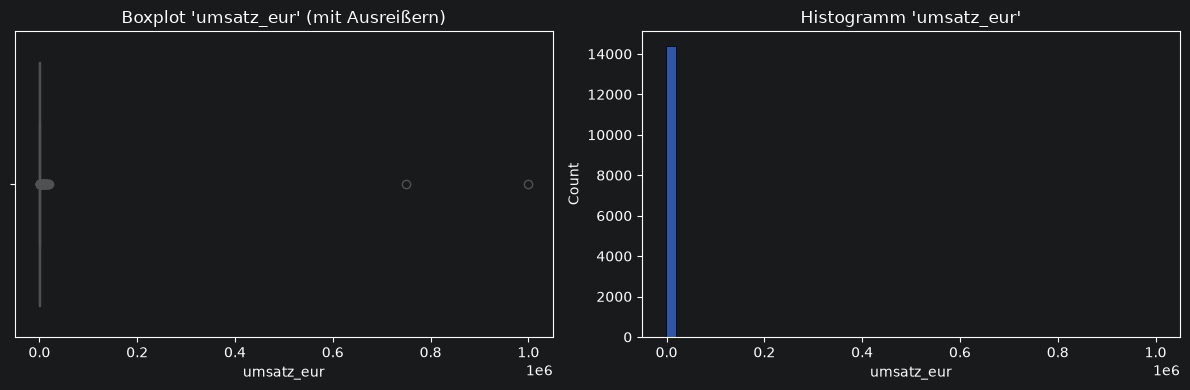

In [79]:
fig, achsen = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_verkaufe_clean["umsatz_eur"], ax=achsen[0])
achsen[0].set_title("Boxplot 'umsatz_eur' (mit Ausreißern)")
sns.histplot(df_verkaufe_clean["umsatz_eur"], bins=50, ax=achsen[1])
achsen[1].set_title("Histogramm 'umsatz_eur'")
plt.tight_layout()
plt.show()

Sowohl Boxplot als auch Histogramm werden durch einzelne extreme
Werte so stark gestaucht, dass die eigentliche Verteilung (der große
Rest der Daten liegt nahe 0) kaum noch erkennbar ist – ein klares
Anzeichen für Ausreißer.

### 4.2 Statistische Übersicht

In [80]:
df_verkaufe_clean["umsatz_eur"].describe()

count    14400.00
mean       638.59
std      10453.46
min       -150.00
25%         70.12
50%        202.78
75%        568.28
max     999999.00
Name: umsatz_eur, dtype: float64

In der statistischen Übersicht ist zu erkennen, dass es Ausreißer nicht nur nach oben gibt, sondern auch negative Umsätze in den Min-Werten stehen. Dadurch wird klar, dass hier mehr Werte auffällig sein müssen, als nur die beiden Extremwerte, wie in 4.1 Boxplot zu sehen.


### 4.3 Extremwerte konkret ansehen

In [81]:
print("Die 5 hoechsten Werte:")
print(df_verkaufe_clean.nlargest(5, "umsatz_eur")[["produkt_id", "monat", "umsatz_eur"]])
print("\nDie 5 niedrigsten Werte:")
print(df_verkaufe_clean.nsmallest(5, "umsatz_eur")[["produkt_id", "monat", "umsatz_eur"]])

Die 5 hoechsten Werte:
      produkt_id      monat  umsatz_eur
11683    PR-0486 2025-08-01   999999.00
5679     PR-0236 2025-04-01   750000.00
9366     PR-0390 2024-07-01    20617.85
9377     PR-0390 2025-06-01    17729.43
11322    PR-0471 2025-07-01    16855.05

Die 5 niedrigsten Werte:
      produkt_id      monat  umsatz_eur
13086    PR-0545 2024-07-01     -150.00
8018     PR-0334 2024-03-01       -1.00
9373     PR-0390 2025-02-01        0.00
6311     PR-0262 2025-12-01        1.63
6301     PR-0262 2025-02-01        1.71


**Beobachtung:** Die höchsten Werte springen um mehrere
Größenordnungen gegenüber dem Rest nach oben (Platzhalter-Muster wie
`999.999` oder `750.000`). Ein negative Umsatz ist fachlich nicht möglich.

### 4.4 Kreuzvalidierung über `vormonat_umsatz_eur`

Die folgende Kreuzvalidierung prüft, ob die Werte in `vormonat_umsatz_eur` fachlich konsistent sind. Für jedes Produkt wird die zeitliche Reihenfolge nach Monat und Jahr hergestellt, sodass der Umsatz des Vormonats exakt dem Umsatz der vorherigen Zeile entsprechen müsste. Durch diese Gegenüberstellung lässt sich erkennen, ob die Historienwerte korrekt berechnet wurden oder ob einzelne Einträge nicht mit der tatsächlichen Umsatzfolge übereinstimmen.

In [82]:
df_verkaufe_clean = df_verkaufe_clean.sort_values(
    ["produkt_id", "monat", "jahr"]
).reset_index(drop=True)

df_verkaufe_clean["vormonat_umsatz_folgezeile_eur"] = (
    df_verkaufe_clean.groupby("produkt_id")["vormonat_umsatz_eur"].shift(-1)
)

df_verkaufe_clean[["produkt_id", "monat", "umsatz_eur", "vormonat_umsatz_folgezeile_eur"]].head(6)

,produkt_id,monat,umsatz_eur,vormonat_umsatz_folgezeile_eur
0,PR-0000,2024-01-01,6.12,6.12
1,PR-0000,2024-02-01,13.64,13.64
2,PR-0000,2024-03-01,16.75,16.75
3,PR-0000,2024-04-01,22.68,22.68
4,PR-0000,2024-05-01,11.98,11.98
5,PR-0000,2024-06-01,9.44,9.44


Die Kreuzvalidierung vergleicht den Umsatz eines Monats mit dem hinterlegten Vormonatswert der Folgezeile. Dadurch lässt sich für jedes Produkt nachvollziehen, ob die Umsatzhistorie korrekt weitergegeben wurde oder ob einzelne Einträge nicht mit der tatsächlichen zeitlichen Reihenfolge übereinstimmen.

In [83]:
vergleichbar = (
    df_verkaufe_clean["vormonat_umsatz_folgezeile_eur"].notna()
    & df_verkaufe_clean["umsatz_eur"].notna()
)
abweichung = vergleichbar & (
    df_verkaufe_clean["vormonat_umsatz_folgezeile_eur"].round(2)
    != df_verkaufe_clean["umsatz_eur"].round(2)
)

print(f"Vergleichbare Zeilen: {vergleichbar.sum()}")
print(f"Uebereinstimmend: {(~abweichung[vergleichbar]).sum()} "
      f"({(~abweichung[vergleichbar]).mean():.4%})")
print(f"Abweichend (= Datenfehler): {abweichung.sum()}")

df_verkaufe_clean.loc[
    abweichung,
    ["produkt_id", "monat", "umsatz_eur", "vormonat_umsatz_folgezeile_eur"],
]

Vergleichbare Zeilen: 13800
Uebereinstimmend: 13795 (99.9638%)
Abweichend (= Datenfehler): 5


,produkt_id,monat,umsatz_eur,vormonat_umsatz_folgezeile_eur
5679,PR-0236,2025-04-01,750000.00,396.94
8018,PR-0334,2024-03-01,-1.00,349.92
9373,PR-0390,2025-02-01,0.00,2797.05
11683,PR-0486,2025-08-01,999999.00,33.49
13086,PR-0545,2024-07-01,-150.00,10.64


Die Prüfung zeigt, dass nahezu alle vergleichbaren Zeilen fachlich konsistent sind: In 13.800 Fällen liegen sowohl der aktuelle Umsatz als auch der Vormonatswert der Folgezeile vor, und davon stimmen 13.795 Einträge exakt überein – eine Übereinstimmungsrate von 99,9638 %. Lediglich 5 Zeilen weichen klar vom erwarteten Wert ab und markieren echte Datenfehler. Diese fehlerhaften Einträge werden durch die Abweichungsmaske eindeutig gekennzeichnet und anschließend tabellarisch ausgegeben, sodass die betroffenen Produkte und Monate sofort sichtbar sind und gezielt korrigiert werden können.

### 4.5 `umsatz_eur` in den abweichenden Zeilen korrigieren

Die Kreuzvalidierung hat gezeigt, dass nur fünf Einträge nicht mit dem tatsächlichen Vormonatswert übereinstimmen. Da der korrekte Wert bereits eindeutig aus der Folgezeile rekonstruiert werden kann, handelt es sich nicht um eine Schätzung, sondern um eine fachlich belastbare Wiederherstellung. Ein Flag markiert transparent, welche Zeilen korrigiert wurden, bevor die Hilfsspalte wieder entfernt wird.


In [84]:
df_verkaufe_clean["umsatz_korrigiert"] = abweichung.astype(int)
df_verkaufe_clean.loc[abweichung, "umsatz_eur"] = (
    df_verkaufe_clean.loc[abweichung, "vormonat_umsatz_folgezeile_eur"].round(2)
)
df_verkaufe_clean = df_verkaufe_clean.drop(columns=["vormonat_umsatz_folgezeile_eur"])

print(f"Korrigierte Werte (umsatz_korrigiert == 1): {df_verkaufe_clean['umsatz_korrigiert'].sum()}")
df_verkaufe_clean.loc[
    df_verkaufe_clean["umsatz_korrigiert"] == 1,
    ["produkt_id", "monat", "umsatz_eur", "umsatz_korrigiert"],
]

Korrigierte Werte (umsatz_korrigiert == 1): 5


,produkt_id,monat,umsatz_eur,umsatz_korrigiert
5679,PR-0236,2025-04-01,396.94,1
8018,PR-0334,2024-03-01,349.92,1
9373,PR-0390,2025-02-01,2797.05,1
11683,PR-0486,2025-08-01,33.49,1
13086,PR-0545,2024-07-01,10.64,1


**Kontrolle:** keine unplausiblen Extremwerte mehr, 0 fehlende Werte in `umsatz_eur`?

In [85]:
print(df_verkaufe_clean["umsatz_eur"].describe())
print(f"\nFehlende Werte in 'umsatz_eur': {df_verkaufe_clean['umsatz_eur'].isna().sum()} (erwartet 0)")

count   14400.00
mean      517.33
std       949.38
min         1.63
25%        70.19
50%       202.82
75%       568.00
max     20617.85
Name: umsatz_eur, dtype: float64

Fehlende Werte in 'umsatz_eur': 0 (erwartet 0)


Insgesamt wurden 5 fehlerhafte Umsatzwerte korrigiert. Die betroffenen Zeilen sind klar gekennzeichnet (umsatz_korrigiert == 1) und enthalten nun den fachlich korrekten Umsatz. Anschließend wurde die Hilfsspalte entfernt, da ihre Information vollständig in den bereinigten Werten steckt. Die abschließende Kontrolle bestätigt eine saubere Verteilung ohne Extremwerte und keine fehlenden Einträge in umsatz_eur. Damit liegt eine vollständig konsistente und plausibel bereinigte Umsatzspalte vor, die für weitere Analysen zuverlässig genutzt werden kann.

## 5 Verbleibende Spalten bereinigen

### 5.1 `lagerbestand` bereinigen

Wie in 2.4 festgestellt, besitzen 288 Zeilen  in dieser Spalte den Text-Zusatz `"Stueck"`.
Dieser Text-Zusatz wird entfernt und der Datentyp auf `int` umgewandelt.

In [86]:
lagerbestand_mit_text = df_verkaufe_clean["lagerbestand"].astype(str).str.contains("[A-Za-z]")
print(f"Zeilen mit Text-Zusatz: {lagerbestand_mit_text.sum()} von {len(df_verkaufe_clean)}")

df_verkaufe_clean["lagerbestand"] = (
    df_verkaufe_clean["lagerbestand"].astype(str)
    .str.replace("Stueck", "", regex=False)
    .str.strip()
    .astype(int)
)
print(f"Datentyp jetzt: {df_verkaufe_clean['lagerbestand'].dtype}")
df_verkaufe_clean["lagerbestand"].describe()

Zeilen mit Text-Zusatz: 288 von 14400
Datentyp jetzt: int64


count   14400.00
mean       74.40
std        43.55
min         1.00
25%        42.00
50%        66.00
75%        97.00
max       441.00
Name: lagerbestand, dtype: float64

**Kontrolle:** kein Text-Zusatz mehr übrig?

In [87]:
noch_text = df_verkaufe_clean["lagerbestand"].astype(str).str.contains("[A-Za-z]").sum()
print(f"Verbleibende Zeilen mit Text: {noch_text} (erwartet 0)")

Verbleibende Zeilen mit Text: 0 (erwartet 0)


Die Umwandlung verlief reibungslos und alle Werte in der Spalte sind nun konsistent.

### 5.2 `bewertungen_durchschnitt` rekonstruieren

In der Spalte `bewertungen_durchschnitt` fehlen 576 Werte. Bevor diese Lücken gefüllt werden, wird geprüft, ob die Bewertung eines Produkts über die Monate hinweg überhaupt variiert. Wenn ein Produkt immer denselben Durchschnittswert besitzt, ist ein fehlender Eintrag kein unbekannter Wert, sondern lediglich eine Lücke im Export.

In [88]:
eindeutige_je_produkt = df_verkaufe_clean.groupby("produkt_id")["bewertungen_durchschnitt"].nunique()
print(f"Produkte mit genau 1 eindeutigem Wert: {(eindeutige_je_produkt == 1).sum()} "
      f"von {df_verkaufe_clean['produkt_id'].nunique()}")

Produkte mit genau 1 eindeutigem Wert: 600 von 600


Die Analyse zeigt, dass alle 600 Produkte über sämtliche Monate hinweg exakt einen eindeutigen Bewertungswert

In [89]:
df_verkaufe_clean["bewertungen_ergaenzt"] = df_verkaufe_clean["bewertungen_durchschnitt"].isna().astype(int)
df_verkaufe_clean["bewertungen_durchschnitt"] = (
    df_verkaufe_clean.groupby("produkt_id")["bewertungen_durchschnitt"].transform(lambda s: s.ffill().bfill())
)

print(f"'bewertungen_ergaenzt' == 1: {df_verkaufe_clean['bewertungen_ergaenzt'].sum()} (erwartet 576)")
print(f"Verbleibend fehlend: {df_verkaufe_clean['bewertungen_durchschnitt'].isna().sum()} (erwartet 0)")

'bewertungen_ergaenzt' == 1: 576 (erwartet 576)
Verbleibend fehlend: 0 (erwartet 0)


Da jede `produkt_id`exakt nur einen eindeutigen Bewertungswert aufzeigt, können die fehlenden Werte mit diesem Wert ergänzt werden. Ein Flag `bewertungen_ergaenzt` markiert die betroffenen Zeilen.

### 5.3 `marketingbudget_eur` auffüllen

In der Spalte `marketingbudget_eur` fehlen insgesamt 433 Werte. Bevor diese Lücken ergänzt werden, wird geprüft, ob das Fehlen systematisch mit anderen Variablen zusammenhängt – etwa mit `kampagne_aktiv` oder der `kategorie`. Nur wenn kein klarer Zusammenhang besteht, ist eine robuste statistische Ergänzung sinnvoll.

In [90]:
fehlquote_kampagne = df_verkaufe_clean.groupby("kampagne_aktiv")["marketingbudget_eur"].apply(lambda s: s.isna().mean())
print("Fehlquote je 'kampagne_aktiv':")
print(fehlquote_kampagne)

median_je_kategorie = df_verkaufe_clean.groupby("kategorie")["marketingbudget_eur"].median()
print("\nMedian je Kategorie:")
print(median_je_kategorie.round(2))

Fehlquote je 'kampagne_aktiv':
kampagne_aktiv
0   0.03
1   0.03
Name: marketingbudget_eur, dtype: float64

Median je Kategorie:
kategorie
Bewaesserung   88.53
Duengemittel   90.72
Pflanzen       87.79
Saatgut        85.58
Toepfe         88.08
Werkzeuge      89.11
Name: marketingbudget_eur, dtype: float64


Da sich weder über `kampagne_aktiv` noch über die `kategorie` ein systematischer Zusammenhang für die fehlenden Marketingbudgets erkennen lässt, da beide Fehlquoten nahezu identisch sind und die Medianwerte der Kategorien eng beieinander liegen, werden die Lücken über den Median je `kategorie` ergänzt. Dieser Ansatz ist bei der rechtsschiefen Verteilung robuster als der Mittelwert. Alle ergänzten Einträge werden über das Flag `marketingbudget_geschaetzt` transparent markiert.

In [91]:
df_verkaufe_clean["marketingbudget_geschaetzt"] = df_verkaufe_clean["marketingbudget_eur"].isna().astype(int)
df_verkaufe_clean["marketingbudget_eur"] = df_verkaufe_clean["marketingbudget_eur"].fillna(
    df_verkaufe_clean["kategorie"].map(median_je_kategorie)
)

print(f"'marketingbudget_geschaetzt' == 1: {df_verkaufe_clean['marketingbudget_geschaetzt'].sum()} "
      f"(433 im Rohdatensatz, davon 1 Zeile als Duplikat entfernt -> erwartet 432)")
print(f"Verbleibend fehlend: {df_verkaufe_clean['marketingbudget_eur'].isna().sum()} (erwartet 0)")

'marketingbudget_geschaetzt' == 1: 432 (433 im Rohdatensatz, davon 1 Zeile als Duplikat entfernt -> erwartet 432)
Verbleibend fehlend: 0 (erwartet 0)


### 5.4 Flags für die bereits korrekten strukturellen NaN-Spalten

Da `vorjahr_monat_umsatz_eur` und `vormonat_umsatz_eur` bereits in Abschnitt 3.7 vollständig mit der fachlichen Logik übereinstimmen, müssen an den Werten selbst keine weiteren Bereinigungen vorgenommen werden. Was jedoch fehlt, sind erklärende Flags, die diese strukturellen NaN‑Situationen transparent markieren.  damit Modelle ohne `NaN`-Unterstützung
diese Information trotzdem nutzen können.

In [92]:
df_verkaufe_clean["hat_vorjahreswert"] = df_verkaufe_clean["vorjahr_monat_umsatz_eur"].notna().astype(int)
df_verkaufe_clean["neues_produkt"] = df_verkaufe_clean["vormonat_umsatz_eur"].isna().astype(int)

print(f"'hat_vorjahreswert' == 0: {(df_verkaufe_clean['hat_vorjahreswert'] == 0).sum()} (erwartet 7.200)")
print(f"'neues_produkt' == 1: {df_verkaufe_clean['neues_produkt'].sum()} (erwartet 600)")

'hat_vorjahreswert' == 0: 7200 (erwartet 7.200)
'neues_produkt' == 1: 600 (erwartet 600)


Die erzeugten Flags treffen exakt die zuvor hergeleiteten Fallzahlen (7.200 bzw. 600) und bestätigen damit die Konsistenz der strukturellen Logik. Mit diesen beiden Markierungen sind nun auch die letzten Spalten des Rohdatensatzes vollständig bereinigt oder fachlich korrekt gekennzeichnet.

## 6 Abschluss

Nach der vollständigen Bereinigung aller Spalten werden im letzten Schritt die finale Struktur des Datensatzes festgelegt. Ziel ist eine logisch nachvollziehbare Reihenfolge, in der jede Kennzahl und jedes Flag direkt neben der zugehörigen Quellspalte steht. Dadurch bleibt die Datenlogik transparent, und alle ergänzten Informationen können von Modellen und Auswertungen ohne zusätzliche Zuordnungsschritte genutzt werden.

### 6.1 Finale Spaltenreihenfolge

Die finale Spaltenreihenfolge ordnet den Datensatz so, dass fachlich zusammengehörige Informationen unmittelbar nebeneinander stehen. Insbesondere werden alle Flags direkt neben ihren Ursprungsspalten platziert, sodass jede Bereinigung und Ergänzung klar erkennbar bleibt.

In [93]:
spalten_reihenfolge = [
    "produkt_id", "kategorie", "hersteller", "monat", "jahr", "monat_idx",
    "preis_eur", "wettbewerber_preis_eur",
    "marketingbudget_eur", "marketingbudget_geschaetzt",
    "kampagne_aktiv", "lagerbestand",
    "bewertungen_durchschnitt", "bewertungen_ergaenzt", "bewertungen_anzahl",
    "vormonat_umsatz_eur", "neues_produkt",
    "letzte_3_monate_umsatz_eur_avg", "hat_3_monats_durchschnitt",
    "vorjahr_monat_umsatz_eur", "hat_vorjahreswert",
    "umsatz_eur", "umsatz_korrigiert",
]
df_verkaufe_clean = df_verkaufe_clean[spalten_reihenfolge]
print(f"Datensatz jetzt: {df_verkaufe_clean.shape[0]} Zeilen, {df_verkaufe_clean.shape[1]} Spalten.")
verbleibend = df_verkaufe_clean.isna().sum()
verbleibend[verbleibend > 0]

Datensatz jetzt: 14400 Zeilen, 23 Spalten.


vormonat_umsatz_eur                600
letzte_3_monate_umsatz_eur_avg    1800
vorjahr_monat_umsatz_eur          7200
dtype: int64

Der Datensatz umfasst nun 23 Spalten in einer konsistenten, logisch aufgebauten Reihenfolge. Alle verbleibenden NaN‑Werte sind strukturell erklärbar und durch entsprechende Flags markiert. Damit liegt eine vollständig bereinigte, klar dokumentierte und modellbereit strukturierte Datenbasis vor.

### 6.2 Als CSV speichern

Im letzten Schritt wird der bereinigte Datensatz gespeichert und die Ergebnisse der gesamten Bereinigung zusammengefasst. Dadurch wird nachvollziehbar, welche Probleme im Rohdatensatz vorhanden waren und wie sie systematisch behoben wurden.

In [94]:
os.makedirs("../data/interim", exist_ok=True)
OUT_PATH = "../data/interim/verkaufe_clean.csv"
df_verkaufe_clean.to_csv(OUT_PATH, index=False, date_format="%Y-%m-%d")

print(f"Gespeichert unter: {OUT_PATH}")
print(f"Finale Form: {df_verkaufe_clean.shape[0]} Zeilen, {df_verkaufe_clean.shape[1]} Spalten "
      f"(Rohdatensatz: {df_verkaufe_raw.shape[0]} Zeilen, {df_verkaufe_raw.shape[1]} Spalten).")

Gespeichert unter: ../data/interim/verkaufe_clean.csv
Finale Form: 14400 Zeilen, 23 Spalten (Rohdatensatz: 14430 Zeilen, 16 Spalten).


## Zusammenfassung

Der Rohdatensatz `verkaufe.csv`, bestehend aus 14.430 Zeilen und 16 Spalten, wirkte auf den ersten Blick vollständig und plausibel. Erst die explorative Analyse zeigte, dass nahezu jede Spalte eigene Format‑ oder Qualitätsprobleme enthielt. Ziel der Datenaufbereitung war es, diese Probleme strukturiert zu identifizieren, fachlich einzuordnen und so zu bereinigen, dass ein konsistenter, modellfertiger Datensatz entsteht, ohne die Rohdatei jemals zu verändern.

Insgesamt wurden acht klar abgegrenzte Datenfehler identifiziert:

1. 30 vollständige Duplikate
– exakt die Differenz zwischen Rohdaten (14.430) und Sollmenge (14.400).

2. 24 Schreibweisen für nur 6 Kategorien
– Groß-/Kleinschreibung, Umlaute, Abkürzungen, Tippvarianten.

3. Drei verschiedene Datumsformate in monat
– MM.YYYY, YYYY-MM, MM/YYYY.

4. `preis_eur` als Textfeld
– gemischte Formate wie "1,50 €" und 1.5.

5. `lagerbestand` mit Textzusatz
– 288 Zeilen mit „Stueck“.

6. `letzte_3_monate_umsatz_eur_avg` fälschlich befüllt
– 1.799 Werte, obwohl die Historie dafür nicht existieren konnte.

7. 5 unplausible Werte in `umsatz_eur`
– Platzhalterwerte (999.999, 750.000) und ein negativer Umsatz.

8. Echte, musterlose Fehlwerte
– 432 fehlende marketingbudget_eur
– 576 fehlende bewertungen_durchschnitt

Für jeden dieser acht Fehler wurde zuerst gesucht und gezählt, wie viele
Zeilen betroffen sind, bevor überhaupt korrigiert wurde. Jede
Korrektur ist über ein eigenes Flag nachvollziehbar (`umsatz_korrigiert`,
`hat_3_monats_durchschnitt`, `bewertungen_ergaenzt`,
`marketingbudget_geschaetzt`, `hat_vorjahreswert`, `neues_produkt`). Wo
der wahre Wert exakt bekannt war (Duplikate, Umsatz-Kreuzvalidierung,
`bewertungen_durchschnitt`), wurde er rekonstruiert statt geschätzt; nur beim
Marketingbudget kam mangels Alternative der Median je Kategorie zum
Einsatz.

Als Ergebnis entstand die `verkaufe_clean.csv` mit 14.400 Zeilen und 23 Spalten, ohne unerklärten Fehlwerten.
Die Rohdatei `verkaufe.csv` selbst wurde zu keinem Zeitpunkt verändert.